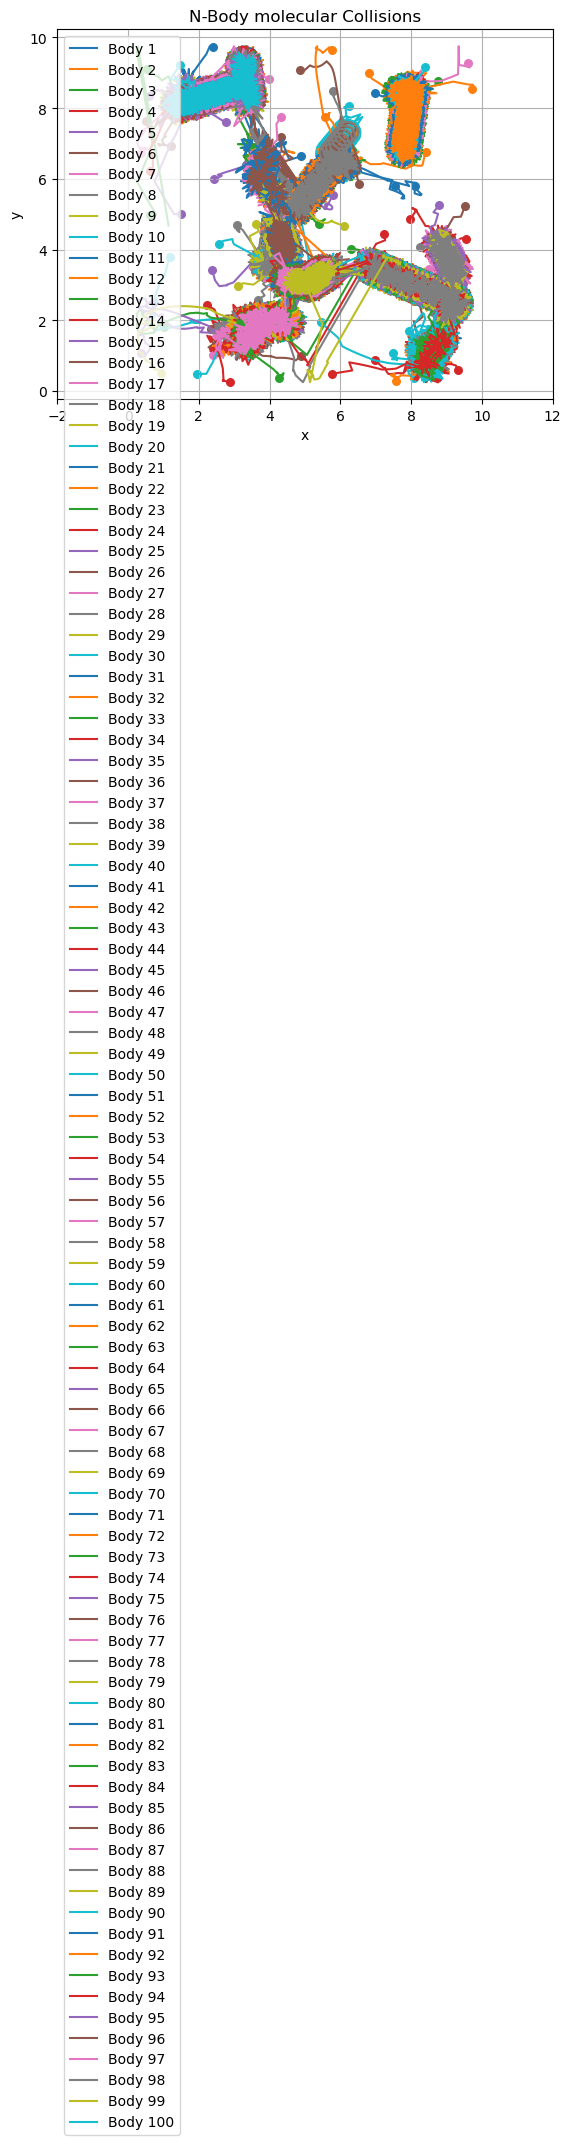

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def parameters():
    dt = 0.01
    total_t = 10
    n = 100
    radius = 0.25
    box_size = 10.0

    iterations = int(total_t / dt)

    r = np.zeros((n, 2, iterations))
    v = np.zeros((n, 2, iterations))
    F = np.zeros((n, 2, iterations))


    for body in range(n):
        while True:
            new_position = np.random.uniform(
                radius, box_size - radius, size=2
            )

  
            if body == 0:
                r[body, :, 0] = new_position
                break

            distances = np.linalg.norm(
                r[:body, :, 0] - new_position,
                axis=1
            )

            if np.all(distances > 2 * radius):
                r[body, :, 0] = new_position
                break

    v[:, :, 0] = np.random.uniform(-2, 2, size=(n, 2))

    return v, r, F, dt, iterations, n, radius, box_size


def position(i):
    r[:, :, i+1] = (
        r[:, :, i]
        + h * v[:, :, i]
        + 0.5 * h**2 * F[:, :, i]
    )


def force(i):
    for a in range(n):
        for b in range(a + 1, n):

 
            dr = r[b, :, i] - r[a, :, i]

            distance = np.linalg.norm(dr)

            if distance <= 3 and distance > 1:
                direction = dr/distance
                F[:,:,i]
            else:
                F[:, :, i+1] = 0


def wall_collisions(i):

    for body in range(n):

  
        if r[body, 0, i] <= radius:
            r[body, 0, i] = radius
            v[body, 0, i] = abs(v[body, 0, i])

        elif r[body, 0, i] >= box_size - radius:
            r[body, 0, i] = box_size - radius
            v[body, 0, i] = -abs(v[body, 0, i])


        if r[body, 1, i] <= radius:
            r[body, 1, i] = radius
            v[body, 1, i] = abs(v[body, 1, i])

        elif r[body, 1, i] >= box_size - radius:
            r[body, 1, i] = box_size - radius
            v[body, 1, i] = -abs(v[body, 1, i])


def particle_collisions(i):

    for a in range(n):
        for b in range(a + 1, n):

 
            dr = r[b, :, i] - r[a, :, i]

            distance = np.linalg.norm(dr)

 
            if distance <= 1 and distance != 0:


                normal = dr / distance

   
                relative_velocity = v[b, :, i] - v[a, :, i]


                speed = np.dot(relative_velocity, normal)

                if speed < 0:

                    v[a, :, i] += speed * normal
                    v[b, :, i] -= speed * normal

                overlap = 2 * radius - distance

                r[a, :, i] -= normal * overlap / 2
                r[b, :, i] += normal * overlap / 2



# -------------------------
# Initialize simulation
# -------------------------

v, r, F, h, iterations, n, radius, box_size = parameters()


# -------------------------
# Run simulation
# -------------------------

for i in range(iterations - 1):

    force(i)

    position(i)

    v[:, :, i+1] = v[:, :, i]


    particle_collisions(i+1)
    wall_collisions(i+1)


# -------------------------
# Plot trajectories
# -------------------------

for body in range(n):

    plt.plot(
        r[body, 0, :],
        r[body, 1, :],
        label=f"Body {body+1}"
    )


    plt.scatter(
        r[body, 0, 0],
        r[body, 1, 0],
        s=30
    )


plt.xlim(0, box_size)
plt.ylim(0, box_size)

plt.xlabel("x")
plt.ylabel("y")
plt.title("N-Body molecular Collisions")

plt.axis("equal")
plt.grid(True)
plt.legend()

plt.show()